<a href="https://colab.research.google.com/github/aerau05/ds3001proj/blob/genomics-lab/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

      0      1       2       3          4       5                    6     \
0  Samples  BM.PB  Gender  Source  tissue.mf  cancer       AFFX-BioB-5_at   
1       39     BM       F    DFCI       BM:f    allB  -1363.2764272403356   
2       40     BM       F    DFCI       BM:f    allB   -796.2850526195647   
3       42     BM       F    DFCI       BM:f    allB   -679.1391678990843   
4       47     BM       M    DFCI       BM:m    allB  -1164.4001971694825   

                  7                   8                    9     ...  \
0       AFFX-BioB-M_at      AFFX-BioB-3_at       AFFX-BioC-5_at  ...   
1  -1058.5854948597048  -541.4691941291975    74.34980300630275  ...   
2   -1167.103364601971  7.5384932304959875    83.54473109024377  ...   
3   -1069.832308213453  -690.3018290509236  -112.07598138565788  ...   
4  -1109.9398910807922  -990.1272176856731  -238.57499366174466  ...   

                  7125                 7126                 7127  \
0            U48730_at            U5

/tmp/ipykernel_2203/1281243344.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = labels.replace({


MSE: 0.0


/tmp/ipykernel_2203/1281243344.py:49: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(residuals, fill=True)


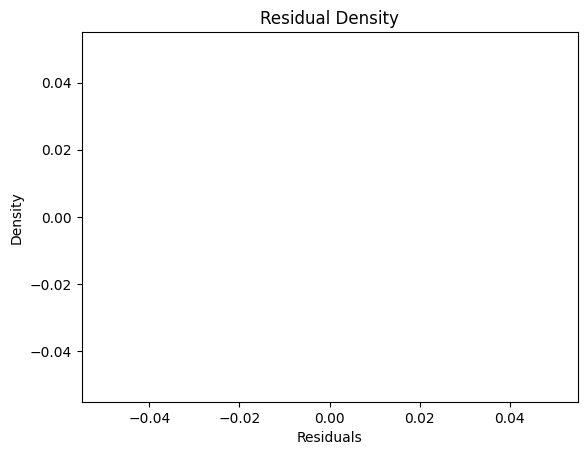

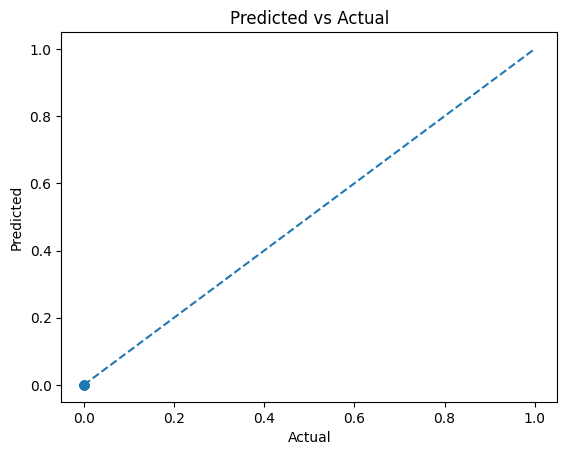

In [20]:
''' 1. Load golub dataset and relabel target variable'''
# load data
import pandas as pd
df = pd.read_csv('/content/golub.csv', header=None)
print(df.head())
# First 6 columns = metadata
metadata = df.iloc[:, :6]

# Column 5 (index 5) = label
labels = df.iloc[:, 5]

# Remaining columns = genes
X = df.iloc[:, 6:]

# Relabel target
labels = df.iloc[:, 5].str.upper()
mask = labels.isin(['ALL', 'ALLB', 'ALLT'])

X = df.iloc[:, 6:][mask]
labels = labels[mask]
y = labels.replace({
    'ALLB': 0,
    'ALLT': 0,
    'ALL': 1
})

'''2. Linear Regression, MSE, kernal density plot, and scatter plot'''
# Fit model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# Mean Squared Error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

# Residuals
residuals = y - y_pred

# Kernel Density Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(residuals, fill=True)
plt.title("Residual Density")
plt.xlabel("Residuals")
plt.show()

# Predicted vs Actual Scatterplot
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

# reference line
plt.plot([0, 1], [0, 1], linestyle='--')
plt.show()
